# 프로젝트 개요 

> * 본 프로젝트는 서울 주요 대학가 주변의 월세 실거래 데이터를 활용하여 지역별 월세 가격 분포를 분석함.
> * 면적·건축년도·층수 등의 요소가 월세에 미치는 영향을 확인하고자 함. 
> * 목표 : 머신러닝 기반 월세 예측 모델을 구축하여 대학생들의 주거 선택에 도움을 주는 것이 목표임.


## 문제정의 


> 부동산 플랫폼 다방의 조사에 따르면, 서울 주요 대학가 원룸의 평균 월세는 지속적으로 상승하고 있다.
최근 조사 기준, 서울 주요 대학가 원룸의 평균 월세는 60만 원 이상이며, 전년 대비 약 6.1% 상승한 것으로 나타났다.

> 특히 대학별 월세 수준에도 차이가 나타났는데, 이화여대 인근은 평균 74.1만 원으로 가장 높았으며, 연세대 64.3만 원, 한국외국어대 63.1만 원, 성균관대 62.5만 원 순으로 조사되었다.<br>

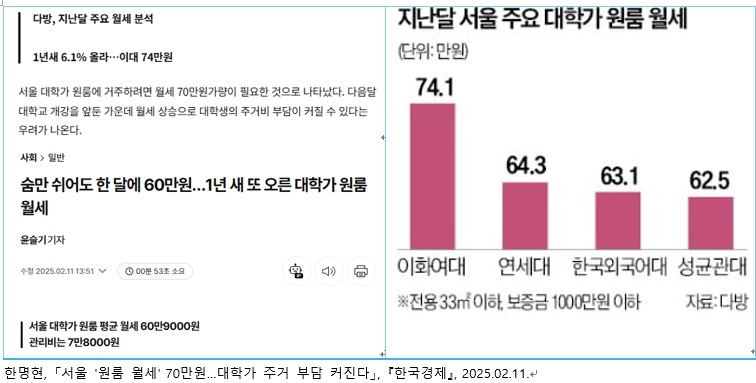

<br>

> 이처럼 대학가별 월세 격차와 지속적인 가격 상승은 대학생들의 주거비 부담을 높이고 있으며, 지역별 주거 비용을 비교·분석할 수 있는 데이터 기반 정보의 필요성이 커지고 있다.

## 기존 솔루션 차별성

| 비교 항목 | 기존 부동산 플랫폼 (직방, 다방, 네이버 부동산) | 본 프로젝트 |
|---|---|---|
| 정보 제공 방식 | 개별 매물 중심 조회 | 지역별 월세 데이터 종합 분석 |
| 가격 비교 방식 | 사용자가 직접 여러 매물 비교 | 대학가별 평균·분포 자동 비교 |
| 가격 판단 기준 | 시세 판단 기준 부족 | 데이터 기반 적정 월세 수준 제시 |
| 분석 가능 요소 | 단순 필터링 (가격, 면적 등) | 면적, 건축년도, 층수 등 영향 요인 분석 |
| 예측 기능 | 없음 | 입력 조건 기반 월세 예측 가능 |
| 대학생 맞춤성 | 일반 사용자 대상 | 대학생 주거 선택 지원에 초점 |
| 활용 목적 | 매물 탐색 | 합리적 지역 선택 및 예산 계획 지원 |

> 기존 부동산 플랫폼은 월세 매물을 확인할 수 있도록 다양한 정보를 제공하지만, 대부분 개별 매물 조회 중심으로 구성되어 있어 지역별 월세 수준을 종합적으로 비교하거나 객관적인 가격 분포를 파악하기 어렵다는 한계가 있다. 또한 사용자가 직접 여러 매물을 비교해야 하므로, 특정 지역의 평균적인 시세나 적정 가격을 판단하기 쉽지 않다.

> 본 프로젝트는 기존 플랫폼이 **“어떤 매물이 있는지 보여주는 서비스”**라면, **“어느 지역이 예산과 조건에 더 적합한지 데이터를 기반으로 판단할 수 있도록 돕는 분석 서비스”**라는 점에서 차별성이 있다.

> 특히 서울 주요 대학가 주변의 월세 데이터를 종합적으로 분석하여 지역별 가격 수준과 분포를 비교하고, 면적·건축년도·층수·대학까지 거리 등의 다양한 요인이 월세에 미치는 영향을 함께 분석한다. 더 나아가 머신러닝 기반의 월세 예측 모델을 통해 사용자가 원하는 조건을 입력하면 예상 월세를 확인할 수 있도록 하여, 대학생들의 합리적인 주거 선택과 예산 계획 수립을 지원하는 **데이터 기반 의사결정 도구**를 목표로 한다.

## 기대효과

1. **대학생의 합리적인 주거 선택 지원**  
   서울 주요 대학가의 지역별 월세 수준과 가격 분포를 비교할 수 있어, 대학생들이 자신의 예산에 맞는 자취 지역을 보다 객관적으로 선택할 수 있다.

2. **월세 가격 결정 요인 분석 및 예측 가능**  
   전용면적, 보증금, 건축년도, 대학까지 거리 등 다양한 요인이 월세에 미치는 영향을 분석하고, 이를 기반으로 예상 월세를 예측하여 적정 가격 판단과 예산 계획 수립에 활용할 수 있다.

3. **향후 주거 추천 서비스로의 확장 가능성**  
   구축한 분석 결과와 예측 모델은 대학생 대상 자취방 추천 서비스, 대학가 월세 비교 플랫폼, 예산 기반 지역 추천 시스템 등 다양한 데이터 기반 부동산 서비스의 기초 자료로 활용될 수 있다.

In [2]:
# 헤더 모음 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

import warnings

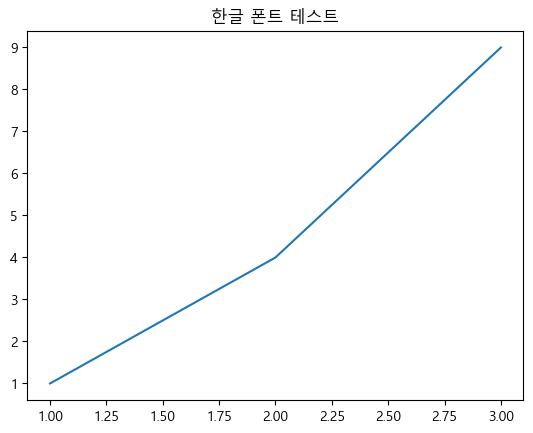

In [6]:
### 한국어 폰트 설정 
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 확인용 테스트
plt.title("한글 폰트 테스트")
plt.plot([1, 2, 3], [1, 4, 9])
plt.show()

## 데이터 확보 및 전처리 

In [342]:
import pandas as pd
# 연립다세대와 오피스텔 데이터 컬럼 구조가 똑같지 않을 수 있으므로,
# 모든 컬럼을 유지한 채 병합하고 없는 값은 NaN으로 채운다.
df1 = pd.read_csv("연립다세대(전월세).csv", encoding='cp949')
df2 = pd.read_csv("오피스텔(전월세).csv", encoding='cp949')

print("연립다세대 shape:", df1.shape
      , " / 오피스텔 shape:", df2.shape)

cols1 = set(df1.columns)
cols2 = set(df2.columns)
common_cols = sorted(cols1 & cols2)
only_in_df1 = sorted(cols1 - cols2)
only_in_df2 = sorted(cols2 - cols1)

print("연립다세대 공통/비공통 컬럼 개수:", len(common_cols), " / ", len(only_in_df1), len(only_in_df2))
print("연립다세대에만 있는 컬럼:", only_in_df1)
print("오피스텔에만 있는 컬럼:", only_in_df2)

load_df = pd.concat([df1, df2], ignore_index=True, sort=False)
df = load_df.copy()

print("load_df shape:", load_df.shape)
load_df.head()

C:\Users\yujaerim\AppData\Local\Temp\ipykernel_16068\1393940653.py:4: DtypeWarning: Columns (0: 종전계약 월세(만원)) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv("연립다세대(전월세).csv", encoding='cp949')


연립다세대 shape: (133808, 21)  / 오피스텔 shape: (92367, 20)
연립다세대 공통/비공통 컬럼 개수: 19  /  2 1
연립다세대에만 있는 컬럼: ['건물명', '주택유형']
오피스텔에만 있는 컬럼: ['단지명']
load_df shape: (226175, 22)


,NO,시군구,번지,본번,부번,건물명,전월세구분,전용면적(㎡),계약년월,계약일,...,층,건축년도,도로명,계약기간,계약구분,갱신요구권 사용,종전계약 보증금(만원),종전계약 월세(만원),주택유형,단지명
0,1,서울특별시 강남구 개포동,1219-3,1219,3,장원,전세,53.42,202605,8,...,2,2013.0,개포로22길 36,202606~202806,신규,-,NaN,NaN,연립다세대,NaN
1,2,서울특별시 강남구 역삼동,728-51,728,51,다올하우스,전세,29.69,202605,8,...,3,2018.0,테헤란로32길 53,202607~202807,신규,-,NaN,NaN,연립다세대,NaN
2,3,서울특별시 중구 신당동,432-1935,432,1935,남산빌라1차,전세,58.19,202605,8,...,2,2003.0,동호로11아길 14,202605~202805,신규,-,NaN,NaN,연립다세대,NaN
3,4,서울특별시 강남구 개포동,1221-10,1221,10,셍상스1,전세,21.76,202605,8,...,2,1996.0,논현로16길 20-3,202608~202707,갱신,사용,"10,400",0,연립다세대,NaN
4,5,서울특별시 종로구 혜화동,22-88,22,88,뉴파인빌2(22-88),월세,27.96,202605,8,...,4,2018.0,혜화로6길 48,202606~202806,신규,-,NaN,NaN,연립다세대,NaN


In [343]:
print(load_df.columns)
print(load_df.info())

Index(['NO', '시군구', '번지', '본번', '부번', '건물명', '전월세구분', '전용면적(㎡)', '계약년월', '계약일',
       '보증금(만원)', '월세금(만원)', '층', '건축년도', '도로명', '계약기간', '계약구분', '갱신요구권 사용',
       '종전계약 보증금(만원)', '종전계약 월세(만원)', '주택유형', '단지명'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 226175 entries, 0 to 226174
Data columns (total 22 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   NO            226175 non-null  int64  
 1   시군구           226175 non-null  str    
 2   번지            226175 non-null  str    
 3   본번            226175 non-null  int64  
 4   부번            226175 non-null  int64  
 5   건물명           133807 non-null  str    
 6   전월세구분         226175 non-null  str    
 7   전용면적(㎡)       226175 non-null  float64
 8   계약년월          226175 non-null  int64  
 9   계약일           226175 non-null  int64  
 10  보증금(만원)       226175 non-null  str    
 11  월세금(만원)       226175 non-null  str    
 12  층             226175 non-null  int64  
 13  건축년도 

### 결측값 처리 및 데이터 정제 
* 학생을 대상으로 하는 데이터기에 전세를 제외한 월세데이터만 남긴다.
* 주택유형의 컬럼의 NA값은 오피스텔로 채운다. 
* 건축년도의 데이터 타입은 int로 통일한다. 
* 갱신요구권 사용 , 종전계약 보증금(만원) , 종전계약 월세(만원) 등 필요없는 데이터의 컬럼은 날린다. 
* 건물명과 단지명의 컬럼을 합쳐 건물디테일이라는 새로운 컬럼을 만든다. 이는 NA를 제거하기 위함이다. 
* index가 2개가 있으면 안되니 NO라는 컬럼은 날린다. 
<br>
<br>

* '번지'컬럼을 자세히 보면 번지수에 안맞는 데이터 양식이나 NA가 존재한다. 이에 대한 문제는 아래와 같이 처리한다.  
    - re 프레임워크를 이용해서 번지 정규식과 안맞는 양식을 찾는다.
    - 만약 양식에 맞지 않거나 , 값이 NA이라면 해당 row를 과감히 드랍한다. 

* 대학가가 있는 지역만을 분석하기 위해서 아래와 같은 구만 선택을 한다. 
    - ['관악구','동작구','성북구','서대문구','광진구']



In [344]:
import re

# 1. 월세 데이터만 남김 (전세 제외)
df = df[df['전월세구분'] == '월세'].copy()

# 2. 주택유형의 NA값을 오피스텔로 채움
df['주택유형'] = df['주택유형'].fillna('오피스텔')

# 3. 건축년도의 NaN을 중앙값으로 채운 후 int로 변환
if '건축년도' in df.columns:
    df['건축년도'] = df['건축년도'].fillna(df['건축년도'].median()).astype(int)

# 4. 불필요한 컬럼 제거
cols_to_drop = ['갱신요구권 사용', '종전계약 보증금(만원)', '종전계약 월세(만원)', 'NO']
cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df = df.drop(columns=cols_to_drop)

# 5. 건물명과 단지명의 컬럼을 합쳐 건물디테일 새로운 컬럼 생성
if '건물명' in df.columns and '단지명' in df.columns:
    df['건물디테일'] = df['건물명'].fillna('') + ' ' + df['단지명'].fillna('')
    df['건물디테일'] = df['건물디테일'].str.strip()
    df['건물디테일'] = df['건물디테일'].replace('', None)
# 기존에 있던 단지명과 건물명의 컬럼은 드랍해줌 
df = df.drop(columns=['건물명', '단지명'], errors='ignore')



# 6. 번지 컬럼 정규식 검증
print(f"\n### 번지 컬럼 검증:")
if '번지' in df.columns:
    print(f"번지의 샘플 값들: {df['번지'].head(10).tolist()}")
    print(f"번지의 null 개수: {df['번지'].isna().sum()}")

    def is_valid_bunji(value):
        if pd.isna(value):
            return False
        pattern = r'^\d+(-\d+)?$'
        return bool(re.match(pattern, str(value).strip()))

    valid_count = df['번지'].apply(is_valid_bunji).sum()
    print(f"유효한 번지 개수: {valid_count}")

    # 양식에 맞지 않는 행 제거
    df = df[df['번지'].apply(is_valid_bunji)].copy()
    print(f"정규식 적용 후: {len(df)} rows")

# 7. 특정 구만 선택 (대학가가 있는 지역)
print(f"\n### 특정 구 선택:")
if '시군구' in df.columns:
    target_districts = ['관악구', '동작구', '성북구', '서대문구', '광진구']
    mask = df['시군구'].astype(str).str.contains('|'.join(target_districts))
    print(f"   필터 대상 구 포함 여부 True rows: {mask.sum()}")
    df = df[mask].reset_index(drop=True)
    print(f"   대학가 구만 선택 후: {len(df)} rows")

print(f"\n최종 데이터셋 shape: {df.shape}")
if len(df) > 0:
    print(f"남은 컬럼: {list(df.columns)}")
    print(f"\n구별 데이터 개수:\n{df['시군구'].value_counts()}")
    print(f"\n결측값 현황:\n{df.isnull().sum()}")


### 번지 컬럼 검증:
번지의 샘플 값들: ['22-88', '248-8', '08월 15일', '09월 17일', '38-51', '2', '111-11', '299-194', '05월 22일', '454-1']
번지의 null 개수: 0
유효한 번지 개수: 135457
정규식 적용 후: 135457 rows

### 특정 구 선택:
   필터 대상 구 포함 여부 True rows: 25147
   대학가 구만 선택 후: 25147 rows

최종 데이터셋 shape: (25147, 17)
남은 컬럼: ['시군구', '번지', '본번', '부번', '전월세구분', '전용면적(㎡)', '계약년월', '계약일', '보증금(만원)', '월세금(만원)', '층', '건축년도', '도로명', '계약기간', '계약구분', '주택유형', '건물디테일']

구별 데이터 개수:
시군구
서울특별시 관악구 봉천동       4015
서울특별시 관악구 신림동       3263
서울특별시 광진구 구의동       1626
서울특별시 광진구 중곡동       1471
서울특별시 광진구 자양동       1282
                    ... 
서울특별시 성북구 동소문동1가       3
서울특별시 서대문구 영천동         2
서울특별시 성북구 보문동3가        1
서울특별시 성북구 보문동4가        1
서울특별시 성북구 안암동4가        1
Name: count, Length: 72, dtype: int64

결측값 현황:
시군구        0
번지         0
본번         0
부번         0
전월세구분      0
전용면적(㎡)    0
계약년월       0
계약일        0
보증금(만원)    0
월세금(만원)    0
층          0
건축년도       0
도로명        0
계약기간       0
계약구분       0
주택유형       0
건물디테일      0
dtype: int64


In [345]:

print(df.columns)
print(df.shape)
df.head(5)

Index(['시군구', '번지', '본번', '부번', '전월세구분', '전용면적(㎡)', '계약년월', '계약일', '보증금(만원)',
       '월세금(만원)', '층', '건축년도', '도로명', '계약기간', '계약구분', '주택유형', '건물디테일'],
      dtype='str')
(25147, 17)


,시군구,번지,본번,부번,전월세구분,전용면적(㎡),계약년월,계약일,보증금(만원),월세금(만원),층,건축년도,도로명,계약기간,계약구분,주택유형,건물디테일
0,서울특별시 광진구 구의동,248-8,248,8,월세,26.82,202605,8,"3,000",70,2,2019,자양로22길 45,202607~202807,신규,연립다세대,두진빌
1,서울특별시 광진구 중곡동,111-11,111,11,월세,45.56,202605,8,"20,000",35,1,2000,천호대로127길 48,202607~202807,신규,연립다세대,청기와아트빌2차
2,서울특별시 성북구 장위동,223-47,223,47,월세,58.37,202605,8,"21,401",21,4,2023,장위로21다길 59-10,202606~202805,갱신,연립다세대,더꿈의숲
3,서울특별시 성북구 장위동,219-193,219,193,월세,26.20,202605,8,50,40,4,2017,장위로13길 39,202605~202805,갱신,연립다세대,남일빌라
4,서울특별시 성북구 정릉동,141-8,141,8,월세,26.24,202605,8,"5,000",70,2,2026,정릉로26길 54,202605~202805,신규,연립다세대,(141-8)


In [346]:
# 각 컬럼들 타입 확인 
print(df.dtypes)

시군구            str
번지             str
본번           int64
부번           int64
전월세구분          str
전용면적(㎡)    float64
계약년월         int64
계약일          int64
보증금(만원)        str
월세금(만원)        str
층            int64
건축년도         int64
도로명            str
계약기간           str
계약구분           str
주택유형           str
건물디테일          str
dtype: object


### 데이터 활용을 위해서 각 컬럼들의 데이터 타입 변환 

* 보증금과 월세가 object형이라 이를 float형으로 변환해줌 

In [347]:
for col in ['보증금(만원)', '월세금(만원)']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '').str.strip(), errors='coerce')

print('변환 후 자료형:')
print(df[['보증금(만원)', '월세금(만원)']].dtypes if {'보증금(만원)', '월세금(만원)'}.issubset(df.columns) else df.dtypes)
print('\n변환 오류 행 수:')
print(df[['보증금(만원)', '월세금(만원)']].isna().sum() if {'보증금(만원)', '월세금(만원)'}.issubset(df.columns) else '컬럼 없음')

변환 후 자료형:
보증금(만원)    int64
월세금(만원)    int64
dtype: object

변환 오류 행 수:
보증금(만원)    0
월세금(만원)    0
dtype: int64


In [348]:
# 중간 데이터 구조 점검 
# 점검을 위해서 CSV로 변환해서 저장

# df.to_csv("intermediate_data.csv", index=False)

In [349]:
df['시군구'].value_counts()

시군구
서울특별시 관악구 봉천동       4015
서울특별시 관악구 신림동       3263
서울특별시 광진구 구의동       1626
서울특별시 광진구 중곡동       1471
서울특별시 광진구 자양동       1282
                    ... 
서울특별시 성북구 동소문동1가       3
서울특별시 서대문구 영천동         2
서울특별시 성북구 보문동3가        1
서울특별시 성북구 보문동4가        1
서울특별시 성북구 안암동4가        1
Name: count, Length: 72, dtype: int64

In [350]:
df.isnull().sum()

시군구        0
번지         0
본번         0
부번         0
전월세구분      0
전용면적(㎡)    0
계약년월       0
계약일        0
보증금(만원)    0
월세금(만원)    0
층          0
건축년도       0
도로명        0
계약기간       0
계약구분       0
주택유형       0
건물디테일      0
dtype: int64

#### 전처리가 끝난 데이터에서 중요 컬럼들만 추출하기 

In [351]:
df.columns

Index(['시군구', '번지', '본번', '부번', '전월세구분', '전용면적(㎡)', '계약년월', '계약일', '보증금(만원)',
       '월세금(만원)', '층', '건축년도', '도로명', '계약기간', '계약구분', '주택유형', '건물디테일'],
      dtype='str')

In [352]:
important_cols = ['월세금(만원)', '보증금(만원)', '전용면적(㎡)', '건축년도', '층']

print(f"결측치 제거 전 데이터 shape: {df.shape}")
df = df.dropna(subset=important_cols)
print(f"결측치 제거 후 데이터 shape: {df.shape}")

결측치 제거 전 데이터 shape: (25147, 17)
결측치 제거 후 데이터 shape: (25147, 17)


### 중요 컬럼들의 분포 시각화하기 

C:\Users\yujaerim\AppData\Local\Temp\ipykernel_16068\2510367213.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count_data.index.astype(str), y=count_data.values, ax=axes[i, 1], palette='viridis')
C:\Users\yujaerim\AppData\Local\Temp\ipykernel_16068\2510367213.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count_data.index.astype(str), y=count_data.values, ax=axes[i, 1], palette='viridis')
C:\Users\yujaerim\AppData\Local\Temp\ipykernel_16068\2510367213.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count_data.index.ast

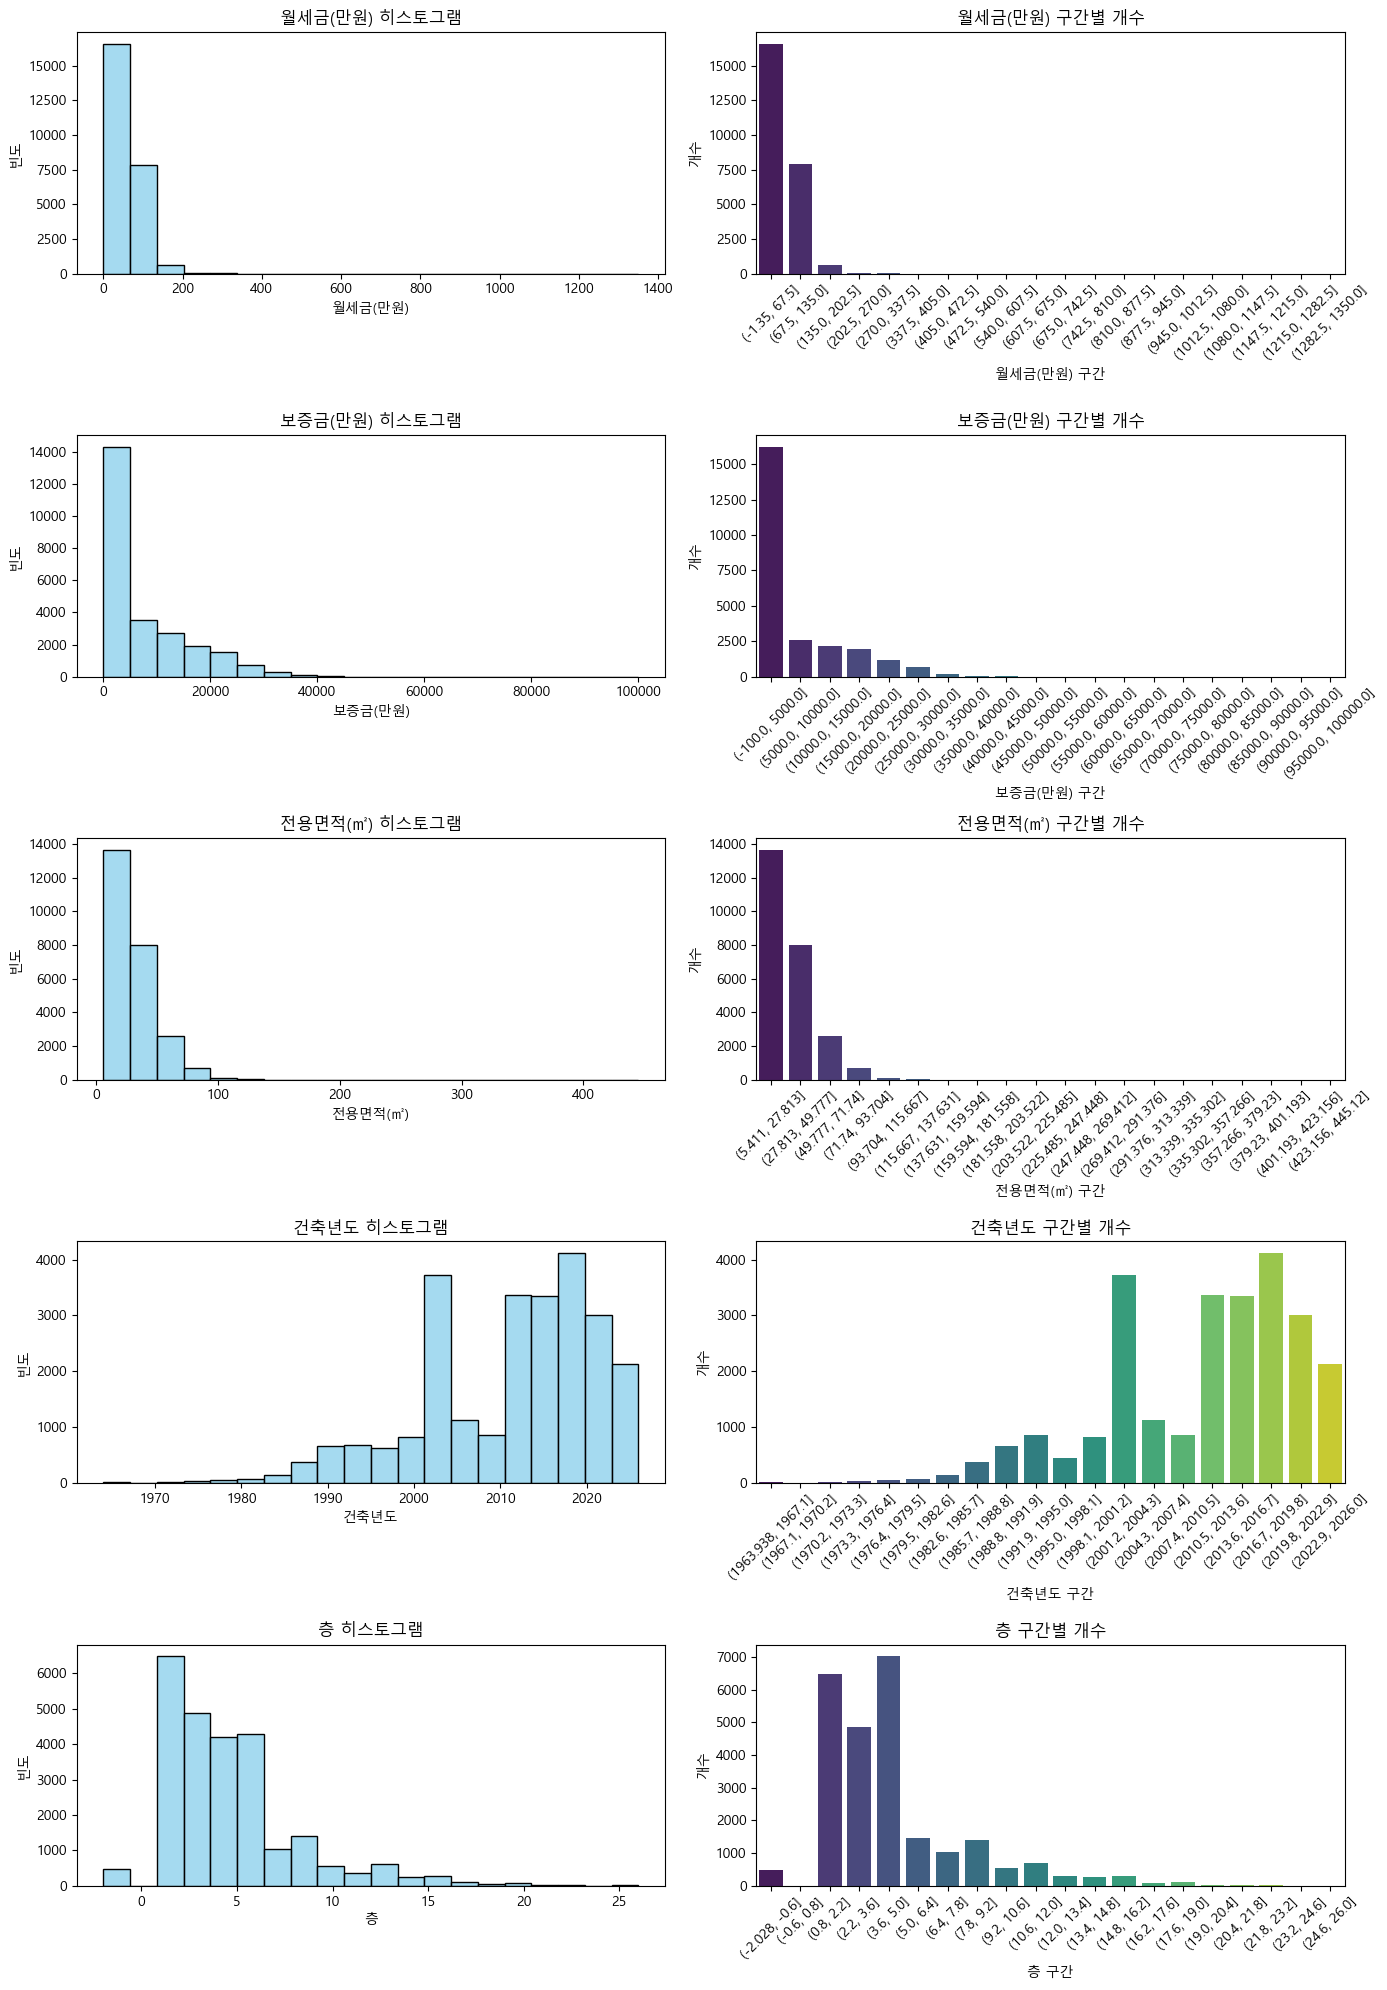

In [353]:
import matplotlib.pyplot as plt
import seaborn as sns

visual_cols = ['월세금(만원)', '보증금(만원)', '전용면적(㎡)', '건축년도', '층']

bin_settings = {
    '월세금(만원)': 20,
    '보증금(만원)': 20,
    '전용면적(㎡)': 20,
    '건축년도': 20,
    '층': 20
}

fig, axes = plt.subplots(len(visual_cols), 2, figsize=(14, 4 * len(visual_cols)))
for i, col in enumerate(visual_cols):
    if col not in df.columns:
        continue

    series = pd.to_numeric(df[col], errors='coerce').dropna()
    if series.empty:
        continue

    n_bins = bin_settings.get(col, 6)
    binned = pd.cut(series, bins=n_bins, duplicates='drop')
    df[f'{col}_구간'] = binned

    sns.histplot(series, bins=n_bins, kde=False, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'{col} 히스토그램')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('빈도')

    count_data = binned.value_counts().sort_index()
    sns.barplot(x=count_data.index.astype(str), y=count_data.values, ax=axes[i, 1], palette='viridis')
    axes[i, 1].set_title(f'{col} 구간별 개수')
    axes[i, 1].set_xlabel(f'{col} 구간')
    axes[i, 1].set_ylabel('개수')
    axes[i, 1].tick_params(axis='x', rotation=45)

fig.tight_layout()
plt.show()

* 시각화만으로 값들의 평균이나 분산을 알 수 없기에 이는 따로 통계를 출력함  

In [354]:
important_cols = ['월세금(만원)', '보증금(만원)', '전용면적(㎡)', '건축년도', '층']

# 숫자형으로 안전하게 변환 후 통계 계산
stats_df = df[important_cols].apply(pd.to_numeric, errors='coerce')

print("기본 통계 정보:")
print(stats_df.describe())

print("\n평균, 표준편차, 중앙값:")
print(stats_df.agg(['mean', 'std', 'median']))

기본 통계 정보:
            월세금(만원)        보증금(만원)       전용면적(㎡)          건축년도             층
count  25147.000000   25147.000000  25147.000000  25147.000000  25147.000000
mean      57.147533    6943.789279     31.104314   2011.131109      4.580268
std       38.137412    8207.487838     18.746219      9.856524      3.451270
min        0.000000       0.000000      5.850000   1964.000000     -2.000000
25%       30.000000    1000.000000     18.120000   2003.000000      2.000000
50%       55.000000    3000.000000     26.430000   2014.000000      4.000000
75%       75.000000   10500.000000     38.820000   2019.000000      5.000000
max     1350.000000  100000.000000    445.120000   2026.000000     26.000000

평균, 표준편차, 중앙값:
          월세금(만원)      보증금(만원)    전용면적(㎡)         건축년도         층
mean    57.147533  6943.789279  31.104314  2011.131109  4.580268
std     38.137412  8207.487838  18.746219     9.856524  3.451270
median  55.000000  3000.000000  26.430000  2014.000000  4.000000


In [355]:
print("\n분산:")
print(stats_df.var())


분산:
월세금(만원)    1.454462e+03
보증금(만원)    6.736286e+07
전용면적(㎡)    3.514207e+02
건축년도       9.715107e+01
층          1.191127e+01
dtype: float64


### 이상치 분포 시각화 (Box Plot) 및 이상치 처리 

* 시각화와 각 컬럼변수에 대한 통계를 관찰한 결과 
    > 
    - 각 이상치들이 조금이지만 존재한다는 것을 알 수 있었다. 
    - 전용면적과 보증금의 부분에서 이상치가 심각하여 학생들을 위한 데이터를 만들때 노이즈로 적용될 수 있다. 
    - 이상치가 얼마나 분포하는지 모르기에 먼저 시각화를 해보고 이를 IQR방식으로 노이즈를 제거하려고 한다. 

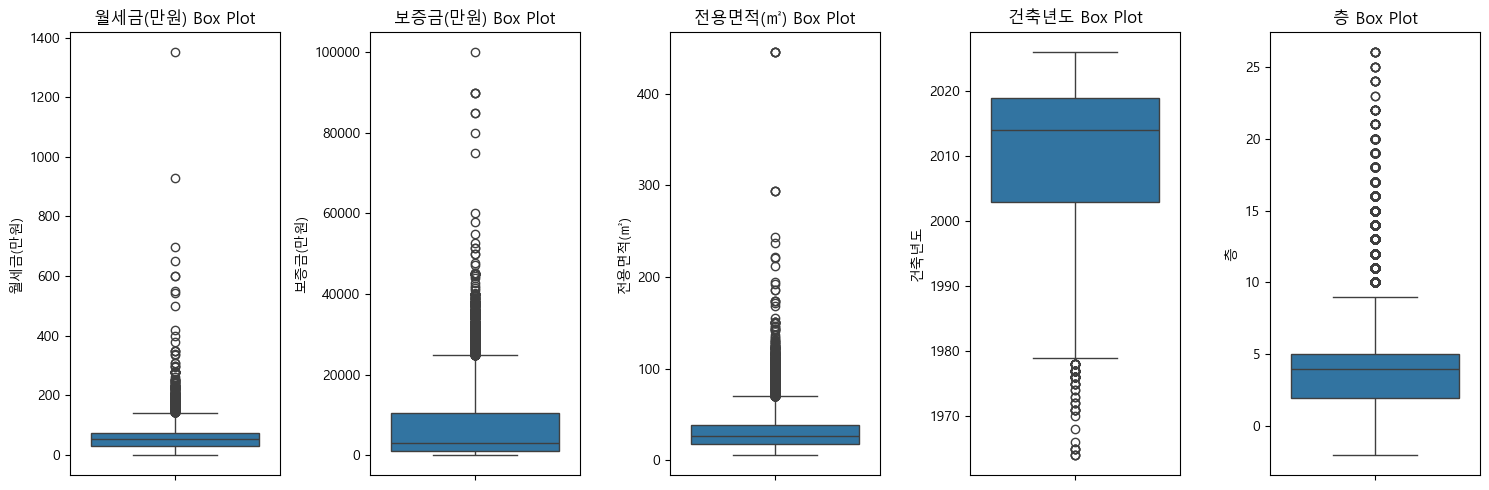

In [356]:
import matplotlib.pyplot as plt
import seaborn as sns

# Box plots for outlier detection
fig, axes = plt.subplots(1, len(important_cols), figsize=(15, 5))
for i, col in enumerate(important_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'{col} Box Plot')
plt.tight_layout()
plt.show()

#### BOX plot 결과 해석
> 데이터 자체가 망가진거라기 보다, 부동산 시장 자체가 이런 데이터 양상을 띄는 경우가 많다. 하지만 우리의 프로젝트는 학생들을 위한 데이터이기에 이러한 이상치들을 없애줘야 한다.

> 그리고 데이터를 처리하는 과정에서 월세인 데이터만 뽑았지만 여기에는 반전세, 준전세 같은 거래가 포함되어 있을 수 있기 때문에 이를 노이즈로 보고 처리를 해야 한다.


#### 1. 월세 box plot 분석
* 월세금(만원) box plot은 전체 분포가 한쪽으로 치우치고, 상위쪽에 극단적인 값들이 존재함을 보여준다.
* 이 점은 일부 고가·고층·신축 매물이 포함되어 있는 경우로 해석되며, 학생 대상 월세 예측 모델에서는 과도한 고가값이 영향을 주지 않도록 제거가 필요하다.
* 또한 상자 내부의 중앙값과 사분위 범위를 확인하면 일반적인 대학가 월세 수준과의 차이를 더 명확히 판단할 수 있다.

#### 2. 보증금 box plot 분석
* 보증금(만원) box plot에서는 매우 낮은 값과 매우 높은 값이 동시에 나타나며, 중간값과 상자 범위가 넓은 편이다.
* 이는 보증금이 0원에 가까운 반전세·준전세 거래나, 높은 보증금의 전세 전환 사례가 혼재된 결과로 보인다.
* 학생 전월세 분석에서는 이러한 극단치가 월세와의 관계를 왜곡할 수 있으므로, 필요 시 보증금 범위를 제한하거나 별도 처리해야 한다.

#### 3. 전용면적 box plot 분석
* 전용면적(㎡) box plot은 대부분 소형 평수에 집중되지만, 일부 넓은 평수 대가 이상치로 나타난다.
* 대학가 월세 시장의 특성을 고려하면 20~30㎡ 내외가 주요 범위이며, 이를 벗어나면 학생용 주거처로서 대표성이 떨어질 수 있다.
* 따라서 모델링 전에는 일반적인 면적 범위대로 데이터를 제한하여 학생 맞춤 분석에 적합한 샘플만 남기는 것이 좋다.

#### 4. 건축년도 box plot 분석
* 건축년도 box plot에서는 비교적 최근 건물들이 집중되지만, 오래된 건물과 매우 신축 건물이 함께 존재한다.
* 오래된 건물의 낮은 임대료와 신축 건물의 높은 임대료가 혼재되면 건축년도 변수의 효과가 불분명해질 수 있다.
* 학생 대상 월세 예측에서는 적절한 연식 범위를 설정하거나, 건축년도를 범주형으로 재코딩해 노이즈를 줄이는 것이 도움이 된다.

## 아웃라이어 처리코드 

In [357]:
# df = pd.read_csv("final_geocoded_data.csv")

In [358]:
# 월세 이상치 제거
Q1 = df['월세금(만원)'].quantile(0.25)
Q3 = df['월세금(만원)'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 정상 범위 데이터만 유지
before_count = len(df)

df = df[(df['월세금(만원)'] >= lower) &
        (df['월세금(만원)'] <= upper)]

after_count = len(df)

print(f'제거 전 데이터 수: {before_count}')
print(f'제거 후 데이터 수: {after_count}')
print(f'제거된 데이터 수: {before_count - after_count}')




제거 전 데이터 수: 25147
제거 후 데이터 수: 24583
제거된 데이터 수: 564


#### 월세 이상치 제거 
* 월세 boxplot에서 확인된 상위 극단값을 제거하여 일반적인 대학가 월세 범위만 남기도록 정제하였다.
* 제거된 데이터는 고급 오피스텔, 초고가 신축 매물, 입력 오류 데이터 등이 포함되었을 가능성이 높다.
* 이를 통해 평균 월세 왜곡을 줄이고, 학생 대상 월세 예측 모델의 안정성을 높일 수 있다.

In [359]:
# 보증금 이상치 제거
Q1 = df['보증금(만원)'].quantile(0.25)
Q3 = df['보증금(만원)'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

before_count = len(df)

# 음수 방지
lower = max(0, lower)

df = df[(df['보증금(만원)'] >= lower) &
        (df['보증금(만원)'] <= upper)]

after_count = len(df)

print(f'제거 전 데이터 수: {before_count}')
print(f'제거 후 데이터 수: {after_count}')
print(f'제거된 데이터 수: {before_count - after_count}')

제거 전 데이터 수: 24583
제거 후 데이터 수: 23749
제거된 데이터 수: 834


#### 보증금 이상치 제거 
* 보증금 데이터에서는 반전세·준전세와 같은 특수 거래 유형이 포함되어 극단적인 값이 존재하였다.
* 지나치게 높은 보증금 데이터는 일반적인 대학생 원룸 시장과 차이가 크므로 제거하였다.
* 이를 통해 월세와 보증금 간 관계를 보다 안정적으로 분석할 수 있게 되었다.

In [360]:
# 전용면적 이상치 제거
Q1 = df['전용면적(㎡)'].quantile(0.25)
Q3 = df['전용면적(㎡)'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

before_count = len(df)

# 너무 작은 면적 방지
lower = max(5, lower)

df = df[(df['전용면적(㎡)'] >= lower) &
        (df['전용면적(㎡)'] <= upper)]

after_count = len(df)

print(f'제거 전 데이터 수: {before_count}')
print(f'제거 후 데이터 수: {after_count}')
print(f'제거된 데이터 수: {before_count - after_count}')

제거 전 데이터 수: 23749
제거 후 데이터 수: 22707
제거된 데이터 수: 1042


#### 전용면적 이상치 제거 
* 대부분의 데이터는 소형 원룸 면적에 집중되어 있었으나 일부 대형 평수 데이터가 이상치로 확인되었다.
* 학생 대상 주거 분석에서는 대형 평수의 대표성이 낮기 때문에 제거를 수행하였다.
* 이를 통해 일반적인 대학가 원룸 특성에 가까운 데이터만 남길 수 있었다.

In [361]:
# 건축년도 이상치 제거
Q1 = df['건축년도'].quantile(0.25)
Q3 = df['건축년도'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

before_count = len(df)

# 현실적인 건축년도 범위 제한
lower = max(1980, lower)
upper = min(2026, upper)

df = df[(df['건축년도'] >= lower) &
        (df['건축년도'] <= upper)]

after_count = len(df)

print(f'제거 전 데이터 수: {before_count}')
print(f'제거 후 데이터 수: {after_count}')
print(f'제거된 데이터 수: {before_count - after_count}')

제거 전 데이터 수: 22707
제거 후 데이터 수: 22615
제거된 데이터 수: 92


#### 건축년도 이상치 제거 
* 지나치게 오래된 건물이나 비정상적인 연도 데이터는 모델 학습 시 노이즈로 작용할 수 있으므로 제거하였다.
* 특히 학생 대상 월세 시장에서는 최근 구축 또는 준신축 건물의 비중이 높기 때문에 일반적인 건축년도 범위 중심으로 데이터를 정제하였다.
* 이를 통해 건축년도 변수와 월세 간 관계를 보다 명확하게 분석할 수 있게 되었다.

## 이상치 제거후 BoxPlot 시각화 

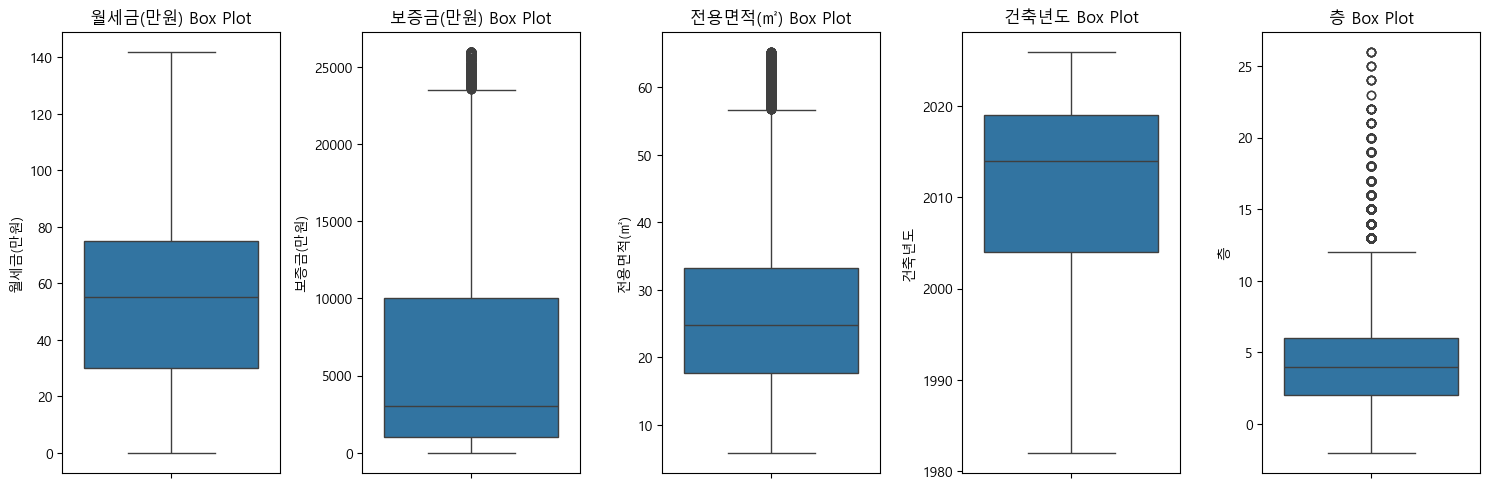

In [362]:
import matplotlib.pyplot as plt
import seaborn as sns

# Box plots for outlier detection
fig, axes = plt.subplots(1, len(important_cols), figsize=(15, 5))
for i, col in enumerate(important_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'{col} Box Plot')
plt.tight_layout()
plt.show()

* 층수의 아웃라이어는 대학가 자취방을 예측함에 있어서 도움이 되는 데이터이기에 아웃라이어를 처리하지 않았다. 

In [363]:
# df.to_csv("final_outlier_removed_data.csv", index=False)
### 아웃라이어 제거 후 데이터 저장
df.shape


(22615, 22)

## 거리 feature 만들기

## Geocoding
주소 → 위경도 변환
방법:

Kakao Developers

회원가입 → REST API key 발급

* 주소 -> 위경도 변환 하기전 주소만들기 

In [3]:
# 중간 저장 파일 불러오기
df = pd.read_csv("final_outlier_removed_data.csv")

# 이거 API불러 올때마다 이거 실행해 줘야지 df에 df를 덮어 쓰는걸 방지할 수 있음 

In [4]:
df["도로명주소"] = df["시군구"] + " " + df["도로명"] 

In [5]:
# 시군구 데이터 갯수 확인 
print(df['시군구'].value_counts())

시군구
서울특별시 관악구 봉천동       3726
서울특별시 관악구 신림동       3016
서울특별시 광진구 구의동       1442
서울특별시 광진구 중곡동       1302
서울특별시 광진구 화양동       1110
                    ... 
서울특별시 서대문구 신촌동         3
서울특별시 성북구 동소문동1가       2
서울특별시 서대문구 영천동         2
서울특별시 성북구 보문동3가        1
서울특별시 성북구 보문동4가        1
Name: count, Length: 71, dtype: int64


In [6]:
# 지오코딩 돌리기 전 표준화 
import re

def normalize_address(addr):

    # 서울
    addr = re.sub(r'^서울시', '서울특별시', addr)

    # 부산
    addr = re.sub(r'^부산시', '부산광역시', addr)

    # 대구
    addr = re.sub(r'^대구시', '대구광역시', addr)

    # 인천
    addr = re.sub(r'^인천시', '인천광역시', addr)

    return addr


def clean_detail(addr):

    # 층/호 제거
    addr = re.sub(r'\d+층', '', addr)
    addr = re.sub(r'\d+호', '', addr)

    # 괄호 제거
    addr = re.sub(r'\(.*?\)', '', addr)

    return addr.strip()

### 표준화 적용 
df['정제주소'] = df['도로명주소'].apply(normalize_address)
df['정제주소'] = df['정제주소'].apply(clean_detail)


In [7]:
# 다시 DF 구조 확인 
print(df.columns)

Index(['시군구', '번지', '본번', '부번', '전월세구분', '전용면적(㎡)', '계약년월', '계약일', '보증금(만원)',
       '월세금(만원)', '층', '건축년도', '도로명', '계약기간', '계약구분', '주택유형', '건물디테일',
       '월세금(만원)_구간', '보증금(만원)_구간', '전용면적(㎡)_구간', '건축년도_구간', '층_구간', '도로명주소',
       '정제주소'],
      dtype='str')


In [8]:
import requests ### 카카오 API받아오기 
from dotenv import load_dotenv
import os

load_dotenv()
KakaoAPI = os.getenv("KakaoAPI")
print(f"Kakao API Key: {KakaoAPI[:5]}...")  # API 키의 앞부분만 출력하여 확인

# 도로명주소를 이용해서 위도 경도 좌표 받아오기 (카카오 API)
# 일단 하나씩 변환하기 ( 테스트 용 )
def geocode(address):
    url = "https://dapi.kakao.com/v2/local/search/address.json"

    # "KakaoAK " 접두사 자동 추가
    if not KakaoAPI.startswith("KakaoAK"):
        auth_header = f"KakaoAK {KakaoAPI}"
    else:
        auth_header = KakaoAPI

    headers = {
        "Authorization": auth_header
    }

    params = {
        "query": address
    }

    res = requests.get(url, headers=headers, params=params)

    data = res.json()

    if res.status_code != 200:
        print(f"에러 응답: {res.text}")  # 상세 에러 메시지 확인
        return None
    
    data = res.json()
    if data.get('documents'):
        x = float(data['documents'][0]['x'])
        y = float(data['documents'][0]['y'])
        return y, x
    return None

Kakao API Key: 3f192...


In [9]:
# 좌표 변환 테스트 
test_address = df["도로명주소"].iloc[0]
print(f"테스트 주소: {test_address}")

test_coords = geocode(test_address)
print(f"테스트 주소 좌표: {test_coords}")


테스트 주소: 서울특별시 광진구 구의동 자양로22길 45
테스트 주소 좌표: (37.5397969820178, 127.085961402919)


### 모든 자취방 주소를 위경도로 변환 (배치 처리)
* 한번에 25000개의 데이터를 다 API로 처리해주면 트래픽이 증가해서 원격연결이 끊어지는 문제가 생긴다.
* 그렇기에 중간중간 나눠서 저장을해준다. 그러면 API가 중간에 끊겨도 저장된 시점부터 다시 시작하면 되니 이러한 문제를 해결할 수 있다. 

In [10]:
import pandas as pd
import time

def batch_geocode_save(
    df,
    address_col='도로명주소',
    start_idx=0,
    save_every=10000,
    delay=0.5,
    save_prefix='geocoded_result'
):

    # 컬럼 생성
    if '위도' not in df.columns:
        df['위도'] = pd.NA

    if '경도' not in df.columns:
        df['경도'] = pd.NA

    failed_indices = []

    total = len(df)

    current_chunk_start = start_idx

    for idx in range(start_idx, total):

        try:

            address = df.loc[idx, address_col]

            # 이미 처리된 경우 skip
            if (
                pd.notna(df.loc[idx, '위도']) and
                pd.notna(df.loc[idx, '경도'])
            ):
                continue

            # 주소 결측
            if pd.isna(address) or address == '':

                df.loc[idx, '위도'] = pd.NA
                df.loc[idx, '경도'] = pd.NA

                failed_indices.append(idx)
                continue

            coords = geocode(address)

            # 성공
            if coords is not None:

                lat, lon = coords

                df.loc[idx, '위도'] = lat
                df.loc[idx, '경도'] = lon

            # 실패
            else:

                df.loc[idx, '위도'] = pd.NA
                df.loc[idx, '경도'] = pd.NA

                failed_indices.append(idx)

            # 진행 상황
            if (idx + 1) % 10 == 0:
                print(f"진행 중: {idx + 1}/{total}")

            # 중간 저장
            if (idx + 1) % save_every == 0:

                filename = (
                    f"{save_prefix}_"
                    f"{current_chunk_start}_{idx}.csv"
                )

                df.to_csv(filename, index=True)

                print(f"[저장 완료] {filename}")

                current_chunk_start = idx + 1

            time.sleep(delay)

        except Exception as e:

            print(f"[에러 발생] index={idx}")
            print(e)

            # 실패 row를 명시적으로 NA 처리
            df.loc[idx, '위도'] = pd.NA
            df.loc[idx, '경도'] = pd.NA

            failed_indices.append(idx)

            time.sleep(2)

    # 마지막 저장
    final_filename = (
        f"{save_prefix}_"
        f"{current_chunk_start}_{total-1}.csv"
    )

    df.to_csv(final_filename, index=True)

    print(f"\n[최종 저장 완료] {final_filename}")

    print("\n=== 완료 ===")
    print(f"총 데이터 수: {total}")
    print(f"실패 개수: {len(failed_indices)}")

    return df, failed_indices

In [11]:
df, failed_idx = batch_geocode_save(
    df,
    start_idx=0,
    save_every=10000,
    delay=1,
    save_prefix='removed_outlier_Data_rent_geocoded'
)

진행 중: 10/22615
진행 중: 20/22615
진행 중: 30/22615
진행 중: 40/22615
진행 중: 50/22615
진행 중: 60/22615
진행 중: 70/22615
진행 중: 80/22615
진행 중: 90/22615
진행 중: 100/22615
진행 중: 110/22615
진행 중: 120/22615
진행 중: 130/22615
진행 중: 140/22615
진행 중: 150/22615
진행 중: 160/22615
진행 중: 170/22615
진행 중: 180/22615
진행 중: 190/22615
진행 중: 200/22615
진행 중: 210/22615
진행 중: 220/22615
진행 중: 230/22615
진행 중: 240/22615
진행 중: 250/22615
진행 중: 260/22615
진행 중: 270/22615
진행 중: 280/22615
진행 중: 290/22615
진행 중: 300/22615
진행 중: 310/22615
진행 중: 320/22615
진행 중: 330/22615
진행 중: 340/22615
진행 중: 350/22615
진행 중: 360/22615
진행 중: 370/22615
진행 중: 380/22615
진행 중: 390/22615
진행 중: 400/22615
진행 중: 410/22615
진행 중: 420/22615
진행 중: 430/22615
진행 중: 440/22615
진행 중: 450/22615
진행 중: 460/22615
진행 중: 470/22615
진행 중: 480/22615
진행 중: 490/22615
진행 중: 500/22615
진행 중: 510/22615
진행 중: 520/22615
진행 중: 530/22615
진행 중: 540/22615
진행 중: 550/22615
진행 중: 560/22615
진행 중: 570/22615
진행 중: 580/22615
진행 중: 590/22615
진행 중: 600/22615
진행 중: 610/22615
진행 중: 620/22615
진행 중: 630/22615
진

#### 좌표 변환 실패한 주소들은 결측값처리를 따로 해줌 

In [12]:
# 컬럼 타입 확인 
print(df.dtypes)

시군구               str
번지                str
본번              int64
부번              int64
전월세구분             str
전용면적(㎡)       float64
계약년월            int64
계약일             int64
보증금(만원)         int64
월세금(만원)         int64
층               int64
건축년도            int64
도로명               str
계약기간              str
계약구분              str
주택유형              str
건물디테일             str
월세금(만원)_구간        str
보증금(만원)_구간        str
전용면적(㎡)_구간        str
건축년도_구간           str
층_구간              str
도로명주소             str
정제주소              str
위도             object
경도             object
dtype: object


In [13]:
# 좌표 변환이 실패한 행들 확인
if failed_idx:
    print(f"좌표 변환 실패한 행 수: {len(failed_idx)}")
    print("실패한 주소 예시:")
    for idx in failed_idx[:5]:  # 상위 5개 예시
        print(f"인덱스: {idx}, 주소: {df['도로명주소'].iloc[idx]}")

좌표 변환 실패한 행 수: 57
실패한 주소 예시:
인덱스: 15520, 주소: 서울특별시 관악구 봉천동 봉천로53길 4-8
인덱스: 16691, 주소: 서울특별시 관악구 봉천동 봉천로53길 4-8
인덱스: 19780, 주소: 서울특별시 관악구 봉천동 봉천로53길 4-8
인덱스: 20208, 주소: 서울특별시 광진구 중곡동 능동로37길 6-1
인덱스: 20209, 주소: 서울특별시 광진구 중곡동 능동로37길 6-1


In [14]:
# 결측값 처리 방법 : 여전히 결측치가 있으면 해당 행 제거 (좌표 변환 실패한 행들)
print("\n### 최종 결측치 제거")
before_count = len(df)
df = df.dropna(subset=['위도', '경도']).reset_index(drop=True)
after_count = len(df)
print(f"최종 제거된 행: {before_count - after_count}개")
print(f"최종 데이터 shape: {df.shape}")



### 최종 결측치 제거
최종 제거된 행: 57개
최종 데이터 shape: (22558, 26)


In [ ]:
# 최종 데이터 저장 (결측값 제거 후)
# df.to_csv("지오코딩_표준화된_data.csv", index=False)

## 거리계산 특징 만들기 


## 거리 계산 방법 

1. 대학 좌표 설정

> 서울 주요 대학(서울대, 고려대, 연세대, 건국대 등)의 위도·경도 좌표를 직접 정의하였다.
각 대학의 대표 위치 좌표를 기준값으로 사용하였다.

2. 매물 좌표 데이터 활용

> 카카오 Local API를 통해 변환한 각 월세 매물의 위도·경도 데이터를 활용하였다.
이를 통해 모든 매물에 대해 위치 기반 분석이 가능하도록 구성하였다.

3. Haversine 공식을 이용한 거리 계산

> 위도·경도 좌표를 기반으로 Haversine 공식을 적용하여 매물과 대학 간의 직선거리를 계산하였다.
계산된 거리는 km 단위로 저장하였다.

4. 가장 가까운 대학 탐색

> 각 매물마다 여러 대학과의 거리를 계산한 뒤, 가장 가까운 대학과 해당 거리를 추출하였다.
이를 통해 대학가 기준의 거리 변수 생성이 가능하도록 하였다.

5. 거리 데이터를 새로운 변수로 저장

> 계산된 결과를 “가장 가까운 대학”, “대학까지 거리(km)” 변수로 저장하여 이후 분석 및 머신러닝 모델의 입력 변수로 활용하였다.

## 거리 계산 방법을 사용한 이유
1. 대학 접근성을 정량적으로 반영하기 위해

> 대학가 월세는 대학과의 거리 영향을 크게 받기 때문에, 단순 지역 정보만으로는 주거 접근성을 충분히 설명하기 어렵다.
따라서 실제 거리 데이터를 활용하여 접근성을 수치화하고자 하였다.

2. 월세 가격과 거리 간 관계를 분석하기 위해

> 대학과 가까운 지역일수록 월세가 높아질 가능성이 있으므로, 거리 변수를 활용하여 거리와 월세 간의 상관관계를 분석하고자 하였다.

3. 머신러닝 모델의 예측 성능 향상을 위해

> 거리 변수는 월세 가격에 영향을 주는 핵심 요인 중 하나로 판단하였다.
따라서 거리 데이터를 입력 변수로 추가하여 예측 모델의 성능 향상을 기대하였다.

4. API 호출 제한 및 처리 속도 문제를 줄이기 위해

> 실시간 길찾기 API 대신 위도·경도 기반 거리 계산 방식을 사용하여 대량 데이터 처리 속도를 높이고 API 호출 제한 문제를 최소화하였다.

5. 데이터 기반 대학가 비교 분석을 수행하기 위해

> 각 매물이 어느 대학권에 속하는지 분석할 수 있도록 하여, 대학별 월세 분포 및 지역 특성을 비교할 수 있도록 하였다.

In [2]:
import pandas as pd 

df = pd.read_csv("지오코딩_표준화된_data.csv")

In [3]:
# 위도 경도 숫자형 변환
df["위도"] = pd.to_numeric(df["위도"], errors="coerce")
df["경도"] = pd.to_numeric(df["경도"], errors="coerce")

# 변환 실패값 제거
df = df.dropna(subset=["위도", "경도"]).reset_index(drop=True)

print(df["위도"].dtypes)
print(df["경도"].dtypes)

float64
float64


In [4]:
### 인접구들 정의 
adjacent_districts = {
    '관악구': ['동작구', '서초구', '금천구'],
    '동작구': ['관악구', '영등포구'],
    '성북구': ['동대문구', '종로구'],
    '서대문구': ['마포구', '은평구'],
    '광진구': ['성동구', '동대문구']
}

In [5]:
universities = { # 주요 학교 5개의 위도 , 경도 좌표, 해당 구 받아오기 
    '서울대': {'coords': (37.4599, 126.9519), 'district': '관악구'},
    '중앙대': {'coords': (37.5051, 126.9571), 'district': '동작구'},
    '숭실대': {'coords': (37.4963, 126.9574), 'district': '동작구'},
    '고려대': {'coords': (37.5894, 127.0324), 'district': '성북구'},
    '연세대': {'coords': (37.5658, 126.9386), 'district': '서대문구'},
    '건국대': {'coords': (37.5408, 127.0793), 'district': '광진구'}
}

In [6]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # 지구 반지름(km)

    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)

    a = (
        sin(dlat / 2)**2
        + cos(radians(lat1))
        * cos(radians(lat2))
        * sin(dlon / 2)**2
    )

    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c

In [7]:
def find_nearest_univ_with_adjacent(row):

    district_text = row["시군구"]

    lat = row["위도"]
    lon = row["경도"]

    # 현재 구 찾기
    current_district = None

    for district in adjacent_districts.keys():
        if district in district_text:
            current_district = district
            break

    # 계산 대상 구
    target_districts = [current_district]

    if current_district in adjacent_districts:
        target_districts += adjacent_districts[current_district]

    min_distance = float("inf")
    nearest_univ = None

    for univ, info in universities.items():

        if info["district"] in target_districts:

            u_lat, u_lon = info["coords"]

            dist = haversine(lat, lon, u_lat, u_lon)

            if dist < min_distance:
                min_distance = dist
                nearest_univ = univ

    return pd.Series([nearest_univ, min_distance])

In [8]:
# 위도/경도 값이 문자열로 들어오면 haversine 계산 중 type error가 발생합니다.
for coord in ["위도", "경도"]:
    if coord in df.columns:
        df[coord] = pd.to_numeric(df[coord], errors="coerce")

# 숫자가 아닌 좌표는 제거하거나 별도 처리
df = df.dropna(subset=["위도", "경도"]).reset_index(drop=True)

df[["가장가까운대학", "대학거리(km)"]] = df.apply(
    find_nearest_univ_with_adjacent,
    axis=1
)

In [9]:
print(df.shape)
print(df.columns)

(22558, 28)
Index(['시군구', '번지', '본번', '부번', '전월세구분', '전용면적(㎡)', '계약년월', '계약일', '보증금(만원)',
       '월세금(만원)', '층', '건축년도', '도로명', '계약기간', '계약구분', '주택유형', '건물디테일',
       '월세금(만원)_구간', '보증금(만원)_구간', '전용면적(㎡)_구간', '건축년도_구간', '층_구간', '도로명주소',
       '정제주소', '위도', '경도', '가장가까운대학', '대학거리(km)'],
      dtype='str')


In [382]:
df.head(10)

,시군구,번지,본번,부번,전월세구분,전용면적(㎡),계약년월,계약일,보증금(만원),월세금(만원),...,월세금(만원)_구간,보증금(만원)_구간,전용면적(㎡)_구간,건축년도_구간,층_구간,도로명주소,위도,경도,가장가까운대학,대학거리(km)
0,서울특별시 광진구 구의동,248-8,248.0,8.0,월세,26.82,202605.0,8.0,3000.0,70.0,...,"(67.5, 135.0]","(-100.0, 5000.0]","(5.411, 27.813]","(2016.7, 2019.8]","(0.8, 2.2]",서울특별시 광진구 구의동 자양로22길 45,37.539797,127.085961,건국대,0.597826
1,서울특별시 광진구 중곡동,111-11,111.0,11.0,월세,45.56,202605.0,8.0,20000.0,35.0,...,"(-1.35, 67.5]","(15000.0, 20000.0]","(27.813, 49.777]","(1998.1, 2001.2]","(0.8, 2.2]",서울특별시 광진구 중곡동 천호대로127길 48,37.554511,127.091213,건국대,1.851326
2,서울특별시 성북구 장위동,223-47,223.0,47.0,월세,58.37,202605.0,8.0,21401.0,21.0,...,"(-1.35, 67.5]","(20000.0, 25000.0]","(49.777, 71.74]","(2022.9, 2026.0]","(3.6, 5.0]",서울특별시 성북구 장위동 장위로21다길 59-10,37.616605,127.045662,고려대,3.242781
3,서울특별시 성북구 장위동,219-193,219.0,193.0,월세,26.20,202605.0,8.0,50.0,40.0,...,"(-1.35, 67.5]","(-100.0, 5000.0]","(5.411, 27.813]","(2016.7, 2019.8]","(3.6, 5.0]",서울특별시 성북구 장위동 장위로13길 39,37.615981,127.042006,고려대,3.074455
4,서울특별시 성북구 정릉동,141-8,141.0,8.0,월세,26.24,202605.0,8.0,5000.0,70.0,...,"(67.5, 135.0]","(-100.0, 5000.0]","(5.411, 27.813]","(2022.9, 2026.0]","(0.8, 2.2]",서울특별시 성북구 정릉동 정릉로26길 54,37.602842,127.012722,고려대,2.289086
5,서울특별시 동작구 사당동,316-254,316.0,254.0,월세,59.53,202605.0,8.0,10000.0,70.0,...,"(67.5, 135.0]","(5000.0, 10000.0]","(49.777, 71.74]","(2010.5, 2013.6]","(3.6, 5.0]",서울특별시 동작구 사당동 사당로20바길 26,37.479495,126.973260,숭실대,2.334518
6,서울특별시 서대문구 홍제동,213-7,213.0,7.0,월세,29.68,202605.0,8.0,18000.0,30.0,...,"(-1.35, 67.5]","(15000.0, 20000.0]","(27.813, 49.777]","(2016.7, 2019.8]","(0.8, 2.2]",서울특별시 서대문구 홍제동 통일로36가길 24,37.588611,126.946098,연세대,2.621116
7,서울특별시 서대문구 홍제동,213-7,213.0,7.0,월세,29.68,202605.0,8.0,18000.0,30.0,...,"(-1.35, 67.5]","(15000.0, 20000.0]","(27.813, 49.777]","(2016.7, 2019.8]","(0.8, 2.2]",서울특별시 서대문구 홍제동 통일로36가길 24,37.588611,126.946098,연세대,2.621116
8,서울특별시 서대문구 남가좌동,73-23,73.0,23.0,월세,38.64,202605.0,8.0,5000.0,120.0,...,"(67.5, 135.0]","(-100.0, 5000.0]","(27.813, 49.777]","(2013.6, 2016.7]","(2.2, 3.6]",서울특별시 서대문구 남가좌동 가재울로8길 5-36,37.575972,126.922304,연세대,1.828110
9,서울특별시 서대문구 북가좌동,3-239,3.0,239.0,월세,40.35,202605.0,8.0,10400.0,30.0,...,"(-1.35, 67.5]","(10000.0, 15000.0]","(27.813, 49.777]","(1985.7, 1988.8]","(0.8, 2.2]",서울특별시 서대문구 북가좌동 증가로24바길 36,37.583014,126.917563,연세대,2.664757


### 거리에 따른 이상치 처리하기 


count    22323.000000
mean         1.876681
std          0.910951
min          0.123206
25%          1.092235
50%          1.841184
75%          2.552059
max          4.767522
Name: 대학거리(km), dtype: float64


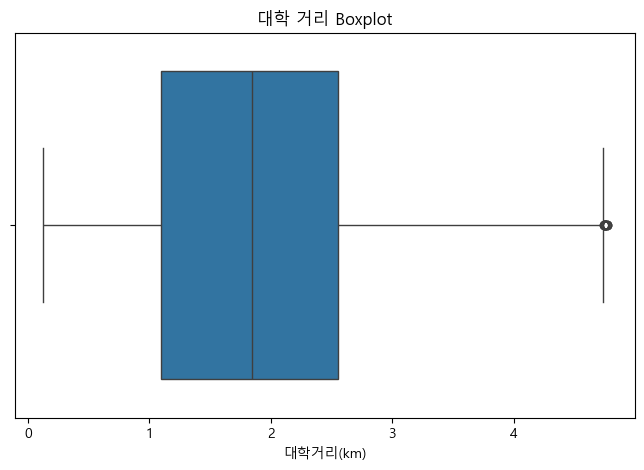

In [19]:
print(df["대학거리(km)"].describe())

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(x=df["대학거리(km)"])

plt.title("대학 거리 Boxplot")

plt.show()

In [11]:
Q1 = df["대학거리(km)"].quantile(0.25)
Q3 = df["대학거리(km)"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("하한:", lower_bound)
print("상한:", upper_bound)


before_shape = df.shape

df = df[
    (df["대학거리(km)"] >= lower_bound) &
    (df["대학거리(km)"] <= upper_bound)
]

after_shape = df.shape

print("제거 전:", before_shape)
print("제거 후:", after_shape)

하한: -1.127118422826769
상한: 4.808227123136199
제거 전: (22558, 28)
제거 후: (22323, 28)


* 대학과의 거리가 비정상적으로 먼 데이터는 실제 대학가 생활권과 관련성이 낮다고 판단하였다. 그래서 이도 IQR로 이상치 제거를 해서 분석의 정확도를 높히고자 했다. 이를 통해 대학가 주변 주거 데이터 중심의 분석 정확도를 높이고자 하였다.

In [12]:
# 거리계산한 데이터 저장
df.to_csv("거리계산_data.csv", index=False)

In [44]:
df = pd.read_csv("거리계산_data.csv") # 거리 계산 , 이상치 제거까지 마친 데이터 불러오기 

In [14]:
df.columns

Index(['시군구', '번지', '본번', '부번', '전월세구분', '전용면적(㎡)', '계약년월', '계약일', '보증금(만원)',
       '월세금(만원)', '층', '건축년도', '도로명', '계약기간', '계약구분', '주택유형', '건물디테일',
       '월세금(만원)_구간', '보증금(만원)_구간', '전용면적(㎡)_구간', '건축년도_구간', '층_구간', '도로명주소',
       '정제주소', '위도', '경도', '가장가까운대학', '대학거리(km)'],
      dtype='str')

## 가설검정 및 분포 분석(EDA) + 시각화 

### 가설 설정
> #### 1. 대학까지 거리가 가까울수록 월세가 높다 (추가적인 특징 검정)
> * 영가설 H₀ : 대학까지 거리와 월세는 관련이 없다.
> * 대립가설 H₁ : 대학까지 거리가 가까울수록 월세가 높다.
> * → 상관분석 (Pearson correlation) 사용

> #### 2. 계약 시기(월/학기)에 따라 평균 월세는 차이가 있다
> * 영가설 H₀ : 계약 시기(월별·학기별)에 따른 평균 월세 차이는 없다.
> * 대립가설 H₁ : 계약 시기에 따라 평균 월세 차이가 존재한다.
> → 일원분산분석(ANOVA) 사용
> → 필요 시 Tukey-HSD 사후검정 수행

In [15]:
import pandas as pd
import numpy as np

import scipy.stats as stats

from statsmodels.stats.multicomp import pairwise_tukeyhsd

import seaborn as sns
import matplotlib.pyplot as plt

#### 가설 1. 대학까지 거리가 가까울수록 월세가 높다

피어슨 상관계수: -0.1189
P-value: 0.000000
→ 거리가 가까울수록 월세가 높아지는 경향


c:\Users\yujaerim\miniconda3\envs\fastapi\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yujaerim\miniconda3\envs\fastapi\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


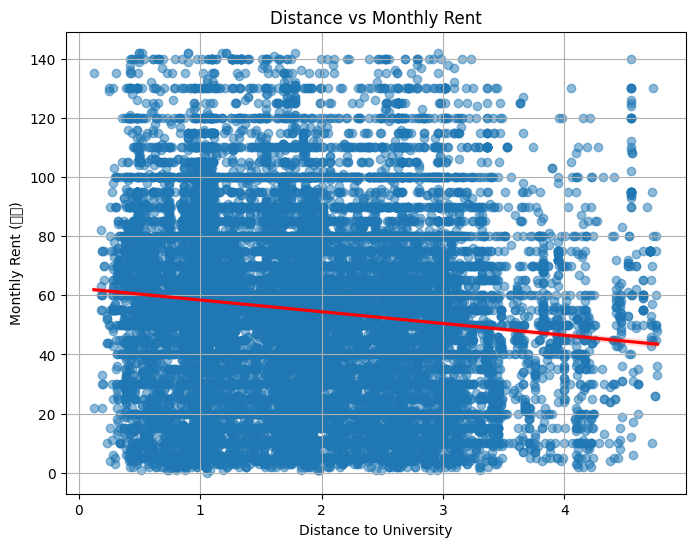

In [16]:
import pandas as pd
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt

# 필요한 컬럼 선택
df_corr = df[['대학거리(km)', '월세금(만원)']].copy()

# 결측치 제거
df_corr = df_corr.dropna()

# 숫자형 변환
df_corr['대학거리(km)'] = pd.to_numeric(df_corr['대학거리(km)'], errors='coerce')
df_corr['월세금(만원)'] = pd.to_numeric(df_corr['월세금(만원)'], errors='coerce')

# 다시 결측 제거
df_corr = df_corr.dropna()

# =========================
# Pearson 상관분석
# =========================
corr, p_value = pearsonr(
    df_corr['대학거리(km)'],
    df_corr['월세금(만원)']
)

print(f"피어슨 상관계수: {corr:.4f}")
print(f"P-value: {p_value:.6f}")

# =========================
# 방향성 해석
# =========================
if corr < 0:
    print("→ 거리가 가까울수록 월세가 높아지는 경향")
elif corr > 0:
    print("→ 거리가 멀수록 월세가 높아지는 경향")
else:
    print("→ 선형 관계가 거의 없음")

# =========================
# 시각화
# =========================
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_corr,
    x='대학거리(km)',
    y='월세금(만원)',
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}   # 회귀선 빨간색
)

plt.title('Distance vs Monthly Rent')
plt.xlabel('Distance to University')
plt.ylabel('Monthly Rent (만원)')
plt.grid(True)

plt.show()

거리구간
0~1km    59.649618
1~2km    56.990612
2~3km    51.138464
3~4km    48.735228
4~5km    52.452436
Name: 월세금(만원), dtype: float64


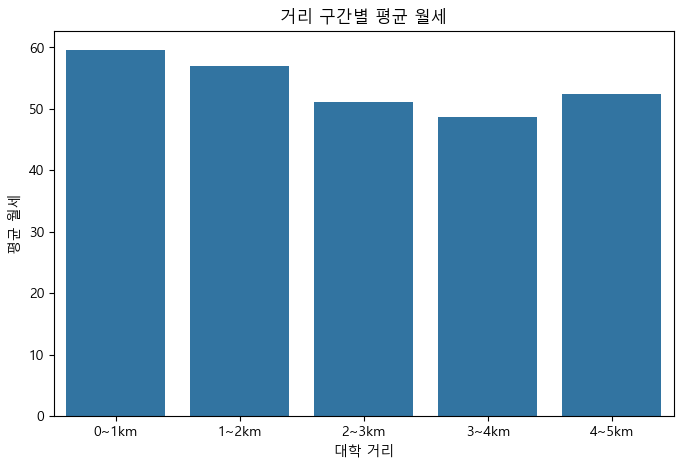

In [20]:
df["거리구간"] = pd.cut(
    df["대학거리(km)"],
    bins=[0,1,2,3,4,5],
    labels=["0~1km","1~2km","2~3km","3~4km","4~5km"]
)

distance_mean = df.groupby("거리구간")["월세금(만원)"].mean()

print(distance_mean)

plt.figure(figsize=(8,5))

sns.barplot(
    x=distance_mean.index,
    y=distance_mean.values
)

plt.title("거리 구간별 평균 월세")

plt.xlabel("대학 거리")

plt.ylabel("평균 월세")

plt.show()

> 거리 구간별 평균 월세를 분석한 결과, 대학과 가까운 구간일수록 평균 월세가 높게 나타나는 경향을 확인할 수 있었다. 특히 0~1km 구간에서 가장 높은 평균 월세를 보였으며, 거리가 멀어질수록 평균 월세가 점차 감소하는 모습을 보였다.

> 다만 4~5km 구간에서는 평균 월세가 다시 소폭 증가하는 경향이 나타났다. 이는 일부 지역의 상권, 교통 접근성, 신축 건물 비중 등의 외부 요인이 함께 영향을 미친 결과로 해석할 수 있다.

> 전체적으로 대학과의 거리는 월세 형성에 일정한 영향을 미치는 변수로 확인되었지만, 거리만으로 월세를 완전히 설명하기는 어려우며 면적, 건축년도, 지역 특성 등의 다양한 요소를 함께 고려할 필요가 있음을 확인할 수 있었다.


#### 가설2. 계약 시기(월/학기)에 따라 평균 월세는 차이가 있다


In [21]:
df.columns

Index(['시군구', '번지', '본번', '부번', '전월세구분', '전용면적(㎡)', '계약년월', '계약일', '보증금(만원)',
       '월세금(만원)', '층', '건축년도', '도로명', '계약기간', '계약구분', '주택유형', '건물디테일',
       '월세금(만원)_구간', '보증금(만원)_구간', '전용면적(㎡)_구간', '건축년도_구간', '층_구간', '도로명주소',
       '정제주소', '위도', '경도', '가장가까운대학', '대학거리(km)', '거리구간'],
      dtype='str')

In [28]:
from scipy.stats import f_oneway

# 계약년월이란 데이터가 `202604.0` 형태로 존재하기에 이를 처리하기위해 월만 추출해서 바꿔줌

# 계약년월 -> 계약월 추출 
df['계약월'] = (
    df['계약년월']
    .astype(int)
    .astype(str)
    .str[-2:]
    .astype(int)
)

df.head(1)

,시군구,번지,본번,부번,전월세구분,전용면적(㎡),계약년월,계약일,보증금(만원),월세금(만원),...,건축년도_구간,층_구간,도로명주소,정제주소,위도,경도,가장가까운대학,대학거리(km),계약월,거래량
0,서울특별시 광진구 구의동,248-8,248,8,월세,26.82,202605,8,3000,70,...,"(2016.7, 2019.8]","(0.8, 2.2]",서울특별시 광진구 구의동 자양로22길 45,서울특별시 광진구 구의동 자양로22길 45,37.539797,127.085961,건국대,0.597826,5,143


In [24]:
from scipy.stats import f_oneway

groups = [
    group['월세금(만원)'].values
    for name, group in df.groupby('계약월')
]

anova_result = f_oneway(*groups)

print(anova_result)

F_onewayResult(statistic=np.float64(10.038940027438935), pvalue=np.float64(1.6878367246881677e-18))


In [25]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df['월세금(만원)'],
    groups=df['계약월'],
    alpha=0.05
)

print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2   0.0832    1.0 -2.6994  2.8659  False
     1      3  -2.7174 0.1102 -5.6836  0.2489  False
     1      4  -6.3553    0.0 -9.6626 -3.0479   True
     1      5  -4.5575 0.0006 -7.9203 -1.1946   True
     1      6  -1.9962 0.5515 -4.9655   0.973  False
     1      7   0.7733 0.9995 -2.2114  3.7579  False
     1      8   1.2974 0.9637 -1.7299  4.3247  False
     1      9  -1.4572 0.9488 -4.6975  1.7831  False
     1     10   -5.152    0.0 -8.3487 -1.9553   True
     1     11  -1.0142 0.9939  -3.977  1.9487  False
     1     12  -2.1956 0.2287 -4.8586  0.4674  False
     2      3  -2.8006 0.1236 -5.9027  0.3015  False
     2      4  -6.4385    0.0 -9.8682 -3.0088   True
     2      5  -4.6407 0.0008 -8.1239 -1.1574   True
     2      6  -2.0795 0.5577 -5.1844  1.0254  False
     2      7     0.69 0.9999 -2.4297  3.8097 

### 월별 ( 계약월별 ) - 월세금 분석하기 
- 거래량 , 월세금 하나의 그래프에 그려서 분석하기 

In [24]:
# 계약월별 거래량 컬럼 생성
monthly_count = (
    df.groupby('계약년월')
    .size()
    .reset_index(name='거래량')
)

# 원본 df에 거래량 컬럼 추가
df = df.merge(
    monthly_count,
    on='계약년월',
    how='left'
)

# 확인
df[['계약년월', '거래량']].head()

,계약년월,거래량
0,202605,143
1,202605,143
2,202605,143
3,202605,143
4,202605,143


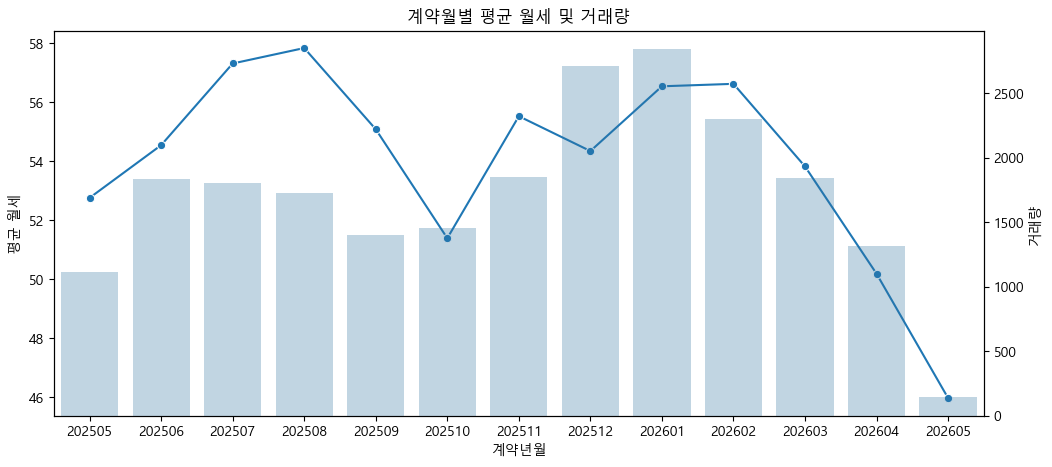

In [25]:
monthly_stats = (
    df.groupby('계약년월')
    .agg(
        평균월세=('월세금(만원)', 'mean'),
        거래량=('월세금(만원)', 'count')
    )
    .reset_index()
)

monthly_stats['계약년월'] = monthly_stats['계약년월'].astype(str)

fig, ax1 = plt.subplots(figsize=(12,5))

# 평균 월세 선그래프
sns.lineplot(
    data=monthly_stats,
    x='계약년월',
    y='평균월세',
    marker='o',
    ax=ax1
)

ax1.set_ylabel('평균 월세')

# 거래량 막대그래프
ax2 = ax1.twinx()

sns.barplot(
    data=monthly_stats,
    x='계약년월',
    y='거래량',
    alpha=0.3,
    ax=ax2
)

ax2.set_ylabel('거래량')

plt.title('계약월별 평균 월세 및 거래량')

plt.xticks(rotation=45)

plt.show()

계약월별 평균 월세 및 거래량 분석 결과, 대학가 월세 시장은 일정 수준의 계절적 변동성을 보이는 것으로 나타났다. 2025년 7~8월과 2026년 1~2월 구간에서는 평균 월세와 거래량이 함께 증가하는 경향이 확인되었으며, 이는 학기 시작 전 주거 수요 증가의 영향을 받은 것으로 해석할 수 있다.

반면 2026년 5월에는 평균 월세가 급격히 감소하는 모습을 보였으나, 해당 시기의 거래량이 매우 적게 나타났다. 따라서 해당 구간은 실제 시장 변화보다는 표본 수 감소에 따른 평균값 왜곡 가능성이 높은 것으로 판단된다.

### 중간값 분석 

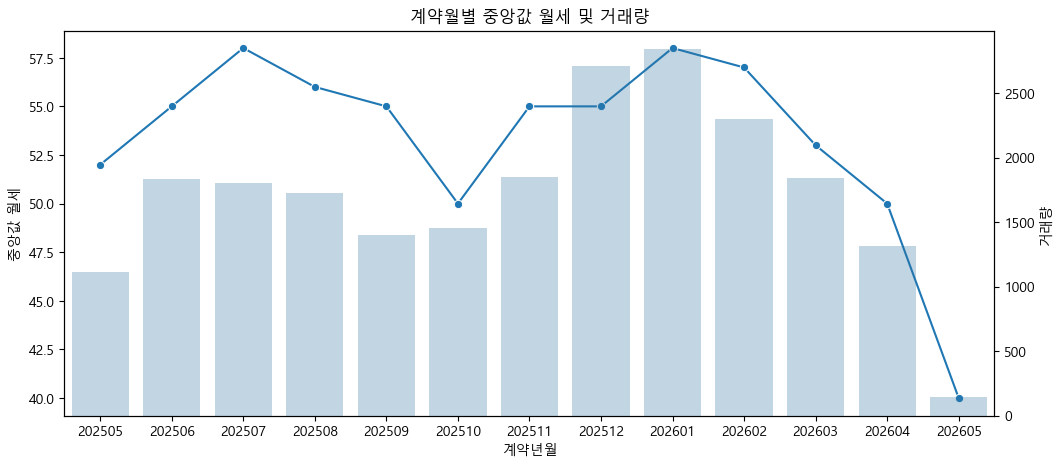

In [27]:
monthly_stats = (
    df.groupby('계약년월')
    .agg(
        중앙값월세=('월세금(만원)', 'median'),
        거래량=('월세금(만원)', 'count')
    )
    .reset_index()
)

monthly_stats['계약년월'] = monthly_stats['계약년월'].astype(str)

fig, ax1 = plt.subplots(figsize=(12,5))

# 중앙값 월세 선그래프
sns.lineplot(
    data=monthly_stats,
    x='계약년월',
    y='중앙값월세',
    marker='o',
    ax=ax1
)

ax1.set_ylabel('중앙값 월세')

# 거래량 막대그래프
ax2 = ax1.twinx()

sns.barplot(
    data=monthly_stats,
    x='계약년월',
    y='거래량',
    alpha=0.3,
    ax=ax2
)

ax2.set_ylabel('거래량')

plt.title('계약월별 중앙값 월세 및 거래량')

plt.xticks(rotation=45)

plt.show()

* 그래프를 분석하니 보통 거래량과 , 월세의 중앙값은 비례하는 것을 볼 수 있다. 
* 계절에 영향을 많이 받는것으로 분석이 되는데 이는 개강시즌과 이런거 땜에 거래량이 증가하면서 
매몰이 없어지고 그에 따라 비싸지는 것으로 분석할 수 있다. 
* 분석 결과, 개강 시즌 전후에는 거래량 증가와 함께 월세 중앙값 또한 상승하는 경향이 나타났다. 반면 상대적으로 수요가 감소하는 시기에는 월세 수준이 안정되거나 낮아지는 모습을 보였다. 따라서 다음 연도 대학가 주변에서 자취를 계획하는 경우, 개강 직전 시기보다는 전년도 방학 기간과 같이 수요가 상대적으로 적은 시기에 계약을 진행하는 것이 보다 유리할 가능성이 있는 것으로 판단된다.

In [29]:
df.to_csv("EDA분석끝난데이터.csv", index=False)

## 모델링

* 2가지 가설에서의 변수 외 변수간의 관계 

In [30]:
import pandas as pd
import numpy as np

df = pd.read_csv("EDA분석끝난데이터.csv")


In [31]:
df.columns

Index(['시군구', '번지', '본번', '부번', '전월세구분', '전용면적(㎡)', '계약년월', '계약일', '보증금(만원)',
       '월세금(만원)', '층', '건축년도', '도로명', '계약기간', '계약구분', '주택유형', '건물디테일',
       '월세금(만원)_구간', '보증금(만원)_구간', '전용면적(㎡)_구간', '건축년도_구간', '층_구간', '도로명주소',
       '정제주소', '위도', '경도', '가장가까운대학', '대학거리(km)', '계약월', '거래량'],
      dtype='str')

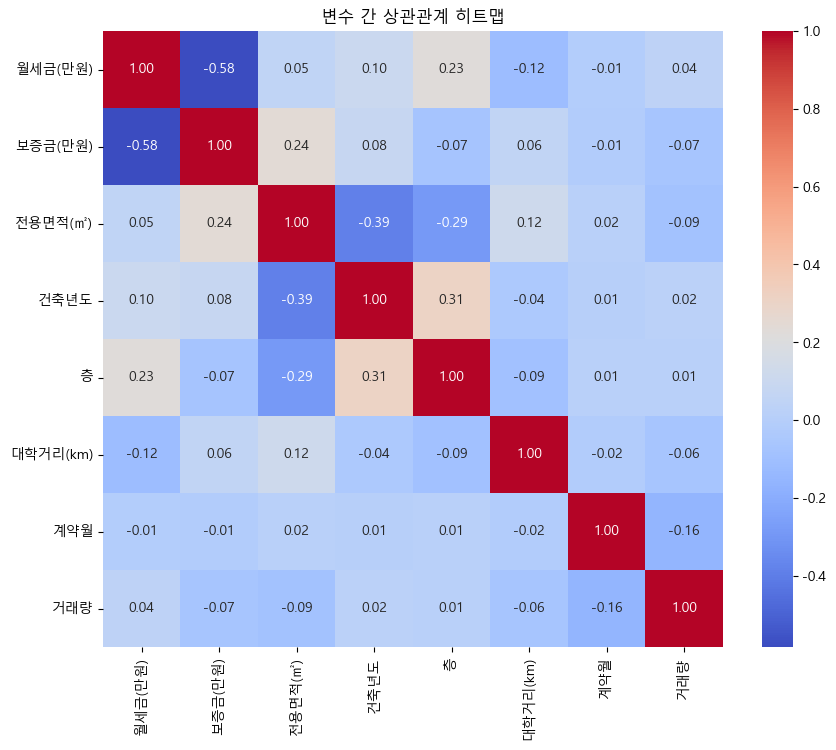

In [32]:
df['계약월'] = (
    df['계약년월']
    .astype(int)
    .astype(str)
    .str[-2:]
    .astype(int)
)

corr = df[[
    '월세금(만원)',
    '보증금(만원)',
    '전용면적(㎡)',
    '건축년도',
    '층',
    '대학거리(km)',
    '계약월',
    '거래량'
]].corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('변수 간 상관관계 히트맵')
plt.show()

### EDA 기반 특징 추출 

In [33]:
X = df[
    [
        '보증금(만원)',
        '전용면적(㎡)',
        '건축년도',
        '층',
        '대학거리(km)',
        '계약월',
        '거래량'
    ]
]

y = df['월세금(만원)']

> * 보증금과 월세는 -0.58의 음의 상관관계를 보였으며, 보증금이 높을수록 월세가 낮아지는 경향이 나타났다. 이는 실제 부동산 월세 거래 구조와 유사한 결과로 볼 수 있다.

> * EDA분석을 통해 대학거리와 월세는 약한 음의 상관관계를 보였으며, 대학과 가까울수록 월세가 다소 높아지는 경향이 확인되었다.

> * 전용면적과 건축년도는 음의 상관관계를 보였는데, 이는 최근 건축된 대학가 원룸일수록 소형 형태가 많기 때문으로 해석할 수 있다.

> * 전체적으로 월세는 하나의 변수만으로 결정되기보다 여러 변수의 복합적인 영향을 받는 것으로 나타났다.

> 계약월과 거래량 변수는 월세와의 선형 상관관계에서는 뚜렷한 관계가 나타나지 않았다. 그러나 계약월별 중앙값 월세 및 거래량 분석에서는 특정 시기에 월세가 상승하는 계절적 패턴이 확인되었다. 따라서 계약월,거래량 변수는 단순 선형관계보다는 계절성과 같은 시간적 특성을 반영하는 변수로 해석할 수 있다.

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [36]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred_lr)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

r2 = r2_score(y_test, y_pred_lr)

print('MAE :', mae)
print('RMSE :', rmse)
print('R² :', r2)

MAE : 16.003701349507732
RMSE : 21.67223483238822
R² : 0.4835116745450454


선형회귀 모델의 성능 평가 결과, 모델은 월세 변동의 약 48% 정도만 설명하는 것으로 나타났다(R²=0.48). 이는 대학가 월세가 단순 선형관계만으로 설명되기 어려우며, 여러 변수들의 복합적인 영향을 받기 때문으로 해석할 수 있다.

따라서 변수 간 관계 구조를 보다 자세히 분석하기 위해 PCA(주성분 분석)를 수행하여 어떤 변수들이 데이터 설명에 큰 영향을 주는지 확인하고자 하였다. 또한 변수 간 다중공선성 여부를 확인하고 이를 분석함으로써 모델 설명력을 개선할 가능성을 탐색하였다.

In [37]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()

vif_df['변수'] = X.columns

vif_df['VIF'] = [
    variance_inflation_factor(
        X.values,
        i
    )
    for i in range(X.shape[1])
]

print(vif_df)

         변수        VIF
0   보증금(만원)   1.921793
1   전용면적(㎡)   6.670078
2      건축년도  34.699746
3         층   3.091082
4  대학거리(km)   5.367332
5       계약월   3.960673
6       거래량  14.330327


다중공선성 분석 결과, 건축년도 변수의 VIF 값이 16 이상으로 매우 높게 나타났다. 이에 이가 예측 결과에 오류를 준다고 생각하고 이를 제외시키고

* 다시 선형회귀를 해본다.

In [39]:

X = df[
    [
        '보증금(만원)',
        '전용면적(㎡)',
        #'건축년도',
        '층',
        '대학거리(km)',
        '계약월',
        '거래량'
    ]
]

y = df['월세금(만원)']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)



mae = mean_absolute_error(y_test, y_pred_lr)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

r2 = r2_score(y_test, y_pred_lr)

print('MAE :', mae)
print('RMSE :', rmse)
print('R² :', r2)

MAE : 17.261211591105305
RMSE : 22.688722827870517
R² : 0.4339259937128973


In [40]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()

vif_df['변수'] = X.columns

vif_df['VIF'] = [
    variance_inflation_factor(
        X.values,
        i
    )
    for i in range(X.shape[1])
]

print(vif_df)

         변수       VIF
0   보증금(만원)  1.902120
1   전용면적(㎡)  5.448504
2         층  2.645970
3  대학거리(km)  4.617611
4       계약월  3.344384
5       거래량  6.853866


> 다중공선성 분석 결과 건축년도 변수의 VIF 값이 높게 나타나 중복 설명 가능성이 확인되었다. 이에 따라 건축년도를 제거한 후 다시 선형회귀 모델을 학습하였다.

> 그러나 건축년도를 제거한 모델의 R² 값은 기존 0.48에서 0.43으로 감소하였으며, MAE와 RMSE 또한 증가하는 모습을 보였다. 이는 건축년도 변수가 다른 변수들과 일부 중복되는 정보를 포함하고 있음에도 불구하고, 월세 설명에 중요한 역할을 하는 변수임을 의미한다.

> 선형회귀 모델 분석 결과, 월세 변동에 대한 설명력이 제한적으로 나타났다(R²=0.48). 또한 히트맵 분석에서도 변수 간 강한 선형 상관관계가 뚜렷하게 나타나지 않았다. 이는 대학가 월세가 단순 선형관계보다는 여러 변수의 복합적·비선형적 영향을 받기 때문으로 해석할 수 있다. 

> 따라서 이러한 패턴을 보다 효과적으로 반영하기 위해 비선형 모델인 RandomForest를 추가적으로 활용하였다.

In [41]:
X = df[ # 변수 다시 선택 - 이번에는 건축년도도 포함해서 돌려보기
    [
        '보증금(만원)',
        '전용면적(㎡)',
        '건축년도',
        '층',
        '대학거리(km)',
        '계약월',
        '거래량'
    ]
]
y = df['월세금(만원)']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print('MAE :', mae_rf)
print('RMSE :', rmse_rf)
print('R² :', r2_rf)

MAE : 9.773318376817285
RMSE : 14.767066537238392
R² : 0.7602041973861393


In [42]:
importance = pd.DataFrame({
    '변수': X.columns,
    '중요도': rf.feature_importances_
})

importance = (
    importance
    .sort_values(
        by='중요도',
        ascending=False
    )
)

print(importance)

         변수       중요도
0   보증금(만원)  0.497743
1   전용면적(㎡)  0.170255
2      건축년도  0.126045
4  대학거리(km)  0.100037
3         층  0.055013
5       계약월  0.025498
6       거래량  0.025409


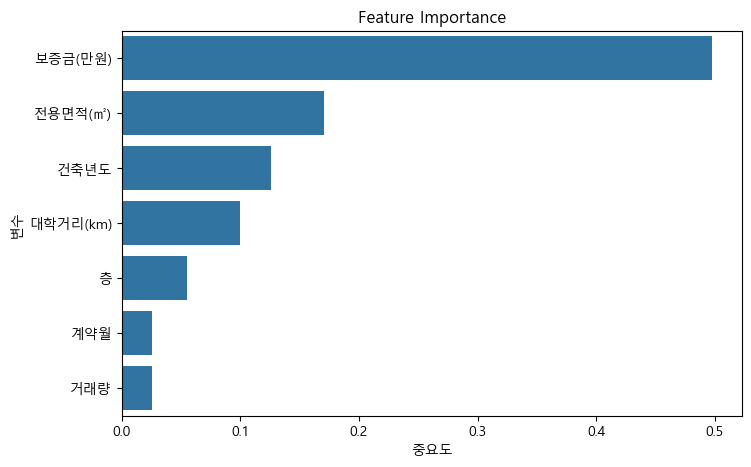

In [43]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='중요도',
    y='변수'
)

plt.title('Feature Importance')

plt.show()

RandomForest 기반 중요도 분석 결과, 보증금과 전용면적이 월세에 가장 큰 영향을 미치는 변수로 나타났다. 특히 보증금 변수의 영향력이 가장 크게 나타났는데, 이는 실제 월세 거래 구조에서 보증금과 월세가 밀접하게 연결되어 있기 때문으로 해석할 수 있다.

반면 대학거리 변수는 상대적으로 낮지만 일정 수준의 중요도를 보였으며, 대학과의 접근성이 월세 형성에 일부 영향을 미친다는 점을 확인할 수 있었다.

계약월,거래량 변수의 중요도는 비교적 낮게 나타났는데, 이는 계절적 영향은 존재하더라도 월세를 결정하는 핵심 요인 수준은 아니었기 때문으로 해석할 수 있다.

In [ ]:
# 2. 변수 영향 분석 (다음 핵심) 
# (2) scatter + 회귀선 
# 이건 발표용으로 강력함. 
# 추천: 
# 대학거리 vs 월세 
# 전용면적 vs 월세 



# 예: 
# sns.regplot( 
#     data=df, 
#     x='대학거리(km)', 
#     y='월세금(만원)' 
# ) 
# (3) boxplot 
# 구간화 이미 해놨으니까 좋음. 



# 추천: 
# 건축년도 구간 vs 월세 
# 면적 구간 vs 월세 
# 3. 모델링 
# 여기가 마지막 핵심. 
# 추천 모델 구조 
# 입력 변수 
# X = [ 
#     '보증금(만원)', 
#     '전용면적(㎡)', 
#     '건축년도', 
#     '층', 
#     '대학거리(km)' 
# ] 
# 타겟 
# y = '월세금(만원)' 

In [ ]:
# 변수를 선택을 할 때 다분공산성도 한번 체크를 함 
# 최대한 독립변수만 남겨서 예측모델을 만들어야함 

In [396]:
# 예측 모델 생성전 특징 최적화 필요함 
# PCA나 LDA같은 차원축소 기법도 한번 써보는 것도 좋음 
# -> 왜냐면 가장 설명을 잘하는 변수를 뽑아서 예측모델을 만들어야하기 때문임

# 예측을 하기전에 표준화 필수임 
# 샘플링 단계에서 클래스 수 맞춰줘야함 
# 오버샘플링은 따로 하지 않음 


## 평가 및 검증